In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

In [2]:
X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [3]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

In [4]:
preprocessor = best_model.named_steps["preprocessor"]

classifier = best_model.named_steps["classifier"]

In [5]:
X_test_transformed = preprocessor.transform(
    X_test
)

In [6]:
feature_names = preprocessor.get_feature_names_out()

In [7]:
print(type(classifier))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [8]:
if isinstance(
    classifier,
    (
        DecisionTreeClassifier,
        RandomForestClassifier,
        GradientBoostingClassifier,
        XGBClassifier
    )
):

    print("Using TreeExplainer")

    explainer = shap.TreeExplainer(classifier)

    shap_values = explainer.shap_values(
        X_test_transformed,
        check_additivity=False
    )

elif isinstance(
    classifier,
    LogisticRegression
):

    print("Using LinearExplainer")

    explainer = shap.LinearExplainer(
        classifier,
        X_test_transformed
    )

    shap_values = explainer.shap_values(
        X_test_transformed
    )

else:

    print("Using Generic Explainer")

    explainer = shap.Explainer(
        classifier.predict,
        X_test_transformed
    )

    shap_values = explainer(
        X_test_transformed
    )

Using TreeExplainer


In [9]:
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

if hasattr(shap_values_plot, "values"):
    shap_matrix = shap_values_plot.values
else:
    shap_matrix = shap_values_plot

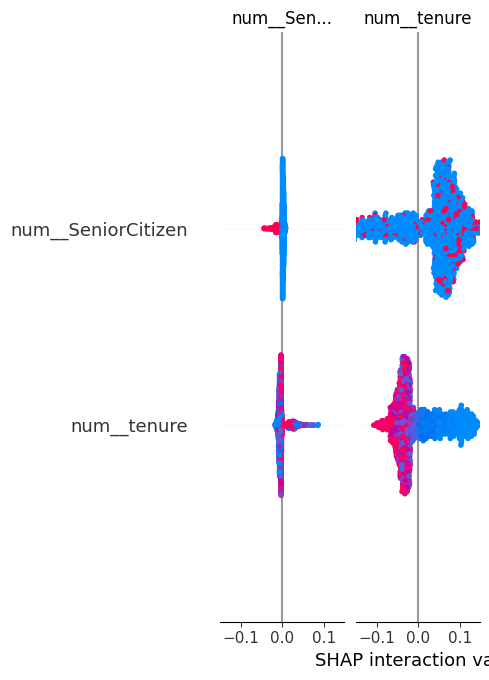

In [10]:
import warnings 
warnings.filterwarnings("ignore")

shap.summary_plot(
    shap_matrix,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.savefig(
    "../reports/shap/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

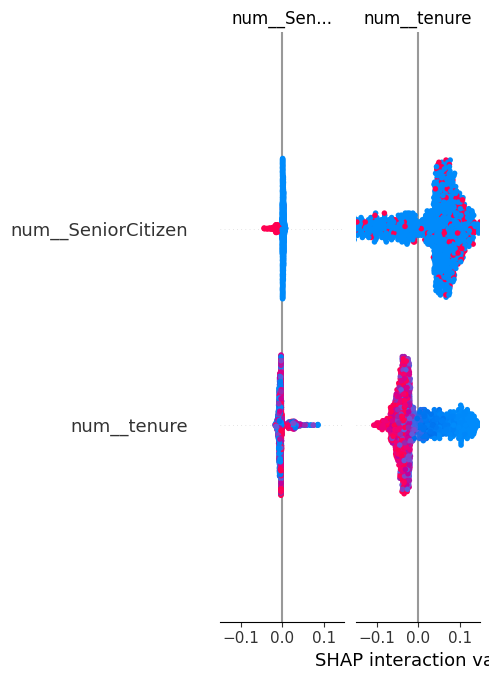

In [11]:
shap.summary_plot(
    shap_matrix,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/shap/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
importance = np.abs(shap_matrix[:, :, 1]).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

In [13]:
importance_df.head(10)

,Feature,Importance
36,cat__Contract_Month-to-month,0.055704
1,num__tenure,0.048241
16,cat__InternetService_Fiber optic,0.033887
18,cat__OnlineSecurity_No,0.029145
3,num__TotalCharges,0.028329
27,cat__TechSupport_No,0.023864
38,cat__Contract_Two year,0.022953
43,cat__PaymentMethod_Electronic check,0.021410
2,num__MonthlyCharges,0.013932
15,cat__InternetService_DSL,0.013595


In [14]:
importance_df.to_csv(
    "../reports/shap/feature_importance.csv",
    index=False
)

importance_df.head(10).to_csv(
    "../reports/shap/top10_features.csv",
    index=False
)

In [15]:
customer_index = 0

if hasattr(shap_values_plot, "values"):
    shap.plots.waterfall(
        shap_values_plot[customer_index],
        show=False
    )

    plt.savefig(
        "../reports/shap/shap_waterfall_customer_1.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("Waterfall plot skipped for this SHAP output format.")

Waterfall plot skipped for this SHAP output format.
